<a href="https://colab.research.google.com/github/Fidelsia/image-segmentation-pascal-voc/blob/main/Neural_Networks_Image_segmentation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Image segmentation
#### 07/08/2024

## Image Segmentation using PASCAL VOC-2012 Dataset

In this part of the project, we will focus on image segmentation, an important task in computer vision that involves dividing an image into meaningful segments or regions. Our specific goal is to perform foreground vs background segmentation using the PASCAL VOC-2012 dataset.

The project will involve:

1. Data Preparation:
   - Download and explore the PASCAL VOC-2012 dataset.
   - Visualize sample images and their corresponding segmentation masks.
   - Prepare the data using TensorFlow's tf.data.Dataset for efficient processing.

2. Model Development:
   - Build a segmentation model, based on the U-Net architecture
   
3. Model Training and Evaluation:
   - Train the segmentation model on the prepared dataset.
   - Visualize the segmentation outputs and compare them with the ground truth references.
   
4. Architecture Experimentation:
   - Modify the model by replacing Conv2DTranspose layers with a combination of UpSampling2D and standard convolution.
   - Compare the performance and visual results of this modified architecture with the original model.





In [ ]:
# mount google drive
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
# Read the dataset
!mkdir -p '/content/voc'
!tar -xf '/content/drive/MyDrive/VOCtrainval_11-May-2012 (1).tar' -C "/content/voc/"  # Extracts the dataset


In [ ]:
# import useful library
import os
from typing import List, Tuple
import tensorflow as tf
import numpy as np
import pandas as pd
import xml.etree.ElementTree as etree
import matplotlib.pyplot as plt
from PIL import Image
from sklearn.model_selection import train_test_split

### 1. Data Exploration
This exploration code below helps us to understand the structure and content of the PASCAL VOC-2012 dataset. We are able to see the images and their masks.

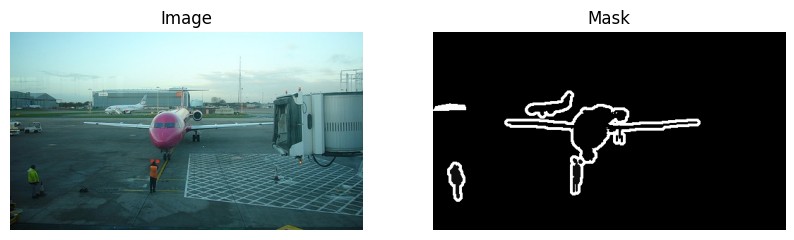

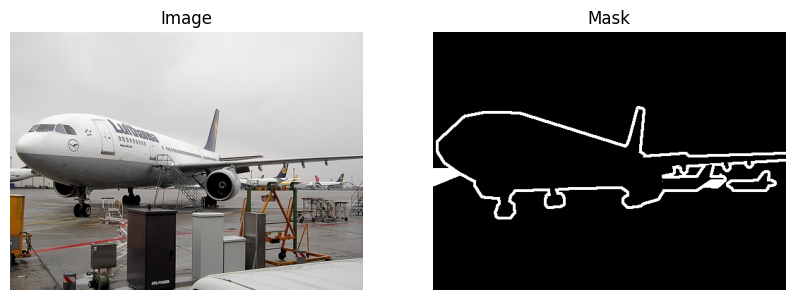

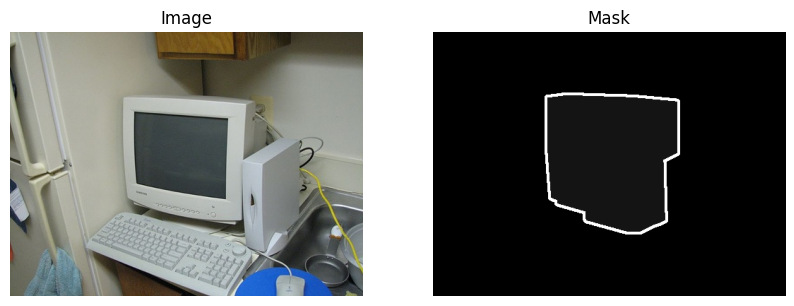

In [ ]:


# Define the path to your VOC dataset
path_to_VOC_folder = '/content/voc/VOCdevkit/VOC2012'

def get_segmentation_paths(base_dir):
    IMAGE_PATH = os.path.join(base_dir, 'JPEGImages')
    ANNOTATION_PATH = os.path.join(base_dir, 'SegmentationClass')
    LISTS = os.path.join(base_dir, 'ImageSets', 'Segmentation')

    image_files_paths = []
    annotations_paths = []

    names = []
    with open(os.path.join(LISTS, 'trainval.txt')) as f:
        for line in f:
            names.append(line.strip())

    for name in names:
        image_files_paths.append(os.path.join(IMAGE_PATH, name + '.jpg'))
        annotations_paths.append(os.path.join(ANNOTATION_PATH, name + '.png'))

    return image_files_paths, annotations_paths

# Get image and mask paths
image_paths, mask_paths = get_segmentation_paths(path_to_VOC_folder)

# Function to display images and masks
def display_image_and_mask(image_path, mask_path, num_samples=3):
    for i in range(num_samples):
        image = np.array(Image.open(image_path[i]))
        mask = np.array(Image.open(mask_path[i]))

        plt.figure(figsize=(10, 5))

        plt.subplot(1, 2, 1)
        plt.title('Image')
        plt.imshow(image)
        plt.axis('off')

        plt.subplot(1, 2, 2)
        plt.title('Mask')
        plt.imshow(mask, cmap='gray')
        plt.axis('off')

        plt.show()

# Display some images and masks
display_image_and_mask(image_paths, mask_paths, num_samples=3)


### 2: Prepare the Dataset

These codes prepare the PASCAL VOC-2012 dataset for the segmentation task, as it is an important step before training the model.

The major steps include defining image dimensions and batch sizes, locating image and mask files, and dividing the dataset into training, validation, and test sets.

By organizing the data this way, the model can be trained effectively and its performance can be evaluated accurately on unseen data.



In [ ]:

# Data preprocessing
# Define image and batch size
_IMAGE_SHAPE = (128, 128)
_BATCH_SIZE = 32

# Path to your VOC dataset
path_to_VOC_folder = '/content/voc/VOCdevkit/VOC2012'

def get_segmentation_paths(base_dir):
    # Returns list of paths to jpg files and png annotations
    IMAGE_PATH = os.path.join(base_dir, 'JPEGImages')
    ANNOTATION_PATH = os.path.join(base_dir, 'SegmentationClass')
    LISTS = os.path.join(base_dir, 'ImageSets', 'Segmentation')

    image_files_paths = []
    annotations_paths = []

    names = []
    with open(os.path.join(LISTS, 'trainval.txt')) as f:
        for line in f:
            names.append(line.strip())

    for name in names:
        image_files_paths.append(os.path.join(IMAGE_PATH, name + '.jpg'))
        annotations_paths.append(os.path.join(ANNOTATION_PATH, name + '.png'))

    return image_files_paths, annotations_paths

# Get image and mask paths
image_paths, mask_paths = get_segmentation_paths(path_to_VOC_folder)

# Split into train, validation, and test sets
X_train, X_temp, y_train, y_temp = train_test_split(image_paths, mask_paths, train_size=0.7, random_state=2022)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, train_size=0.5, random_state=2022)


### Create Data Pipeline

This is part of the data preparation process.

The code creates an efficient data pipeline for processing image and mask pairs for the image segmentation process.

It defines functions to load and preprocess images and their corresponding masks, resizing them to a specified shape and converting masks to binary format.

The code then sets up TensorFlow datasets for training, validation, and testing. These datasets apply the preprocessing functions to each image-mask pair, shuffle the training data for better learning, organize the data into batches, and optimize data loading for improved performance. This pipeline ensures that data is prepared and fed efficiently into the model during training and evaluation processes.

In [ ]:
# Datapipeline creation

def load_image_and_mask(im_path, mask_path):
    img_raw = tf.io.read_file(im_path)
    img = tf.io.decode_image(img_raw, channels=3, dtype=tf.float32)
    img = tf.image.resize(img, _IMAGE_SHAPE)

    mask_raw = tf.io.read_file(mask_path)
    mask = tf.image.decode_png(mask_raw, channels=1)
    mask = tf.image.resize(mask, _IMAGE_SHAPE, method=tf.image.ResizeMethod.NEAREST_NEIGHBOR)
    mask = tf.cast(mask, tf.int32)
    mask = tf.where(mask > 0, 1, 0)

    return img, mask

def load_image_and_mask_wrapper(im_path, mask_path):
    img, mask = tf.py_function(load_image_and_mask, [im_path, mask_path], [tf.float32, tf.int32])
    img.set_shape((_IMAGE_SHAPE[0], _IMAGE_SHAPE[1], 3))
    mask.set_shape((_IMAGE_SHAPE[0], _IMAGE_SHAPE[1], 1))
    return img, mask

train_dataset = tf.data.Dataset.from_tensor_slices((X_train, y_train))
train_dataset = train_dataset.map(load_image_and_mask_wrapper, num_parallel_calls=tf.data.AUTOTUNE)
train_dataset = train_dataset.shuffle(buffer_size=1000).batch(_BATCH_SIZE).prefetch(tf.data.AUTOTUNE)

val_dataset = tf.data.Dataset.from_tensor_slices((X_val, y_val))
val_dataset = val_dataset.map(load_image_and_mask_wrapper, num_parallel_calls=tf.data.AUTOTUNE)
val_dataset = val_dataset.batch(_BATCH_SIZE).prefetch(tf.data.AUTOTUNE)

test_dataset = tf.data.Dataset.from_tensor_slices((X_test, y_test))
test_dataset = test_dataset.map(load_image_and_mask_wrapper, num_parallel_calls=tf.data.AUTOTUNE)
test_dataset = test_dataset.batch(_BATCH_SIZE).prefetch(tf.data.AUTOTUNE)


### Build U-net model

This code implements a U-Net architecture for image segmentation.
* The U-Net model is built using a series of convolutional and pooling layers in the encoder (downsampling) path, followed by upsampling and convolutional layers in the decoder path.

* Skip connections are used to concatenate features from the encoder to the decoder, helping preserve spatial information.
* The final layer uses a sigmoid activation for binary segmentation. The model is then compiled with an Adam optimizer, binary crossentropy loss, and accuracy metric.

This architecture is designed to effectively capture and combine both low-level and high-level features for accurate image segmentation.

In [ ]:
# Model building

from tensorflow.keras.layers import Input, Conv2D, MaxPooling2D, UpSampling2D, concatenate
from tensorflow.keras.models import Model

def build_unet_model(input_shape):
    inputs = Input(input_shape)

    # Encoder
    c1 = Conv2D(64, (3, 3), activation='relu', padding='same')(inputs)
    c1 = Conv2D(64, (3, 3), activation='relu', padding='same')(c1)
    p1 = MaxPooling2D((2, 2))(c1)

    c2 = Conv2D(128, (3, 3), activation='relu', padding='same')(p1)
    c2 = Conv2D(128, (3, 3), activation='relu', padding='same')(c2)
    p2 = MaxPooling2D((2, 2))(c2)

    c3 = Conv2D(256, (3, 3), activation='relu', padding='same')(p2)
    c3 = Conv2D(256, (3, 3), activation='relu', padding='same')(c3)
    p3 = MaxPooling2D((2, 2))(c3)

    c4 = Conv2D(512, (3, 3), activation='relu', padding='same')(p3)
    c4 = Conv2D(512, (3, 3), activation='relu', padding='same')(c4)
    p4 = MaxPooling2D(pool_size=(2, 2))(c4)

    # Bottleneck
    c5 = Conv2D(1024, (3, 3), activation='relu', padding='same')(p4)
    c5 = Conv2D(1024, (3, 3), activation='relu', padding='same')(c5)

    # Decoder
    u6 = UpSampling2D((2, 2))(c5)
    u6 = Conv2D(512, (2, 2), activation='relu', padding='same')(u6)
    u6 = concatenate([u6, c4])
    c6 = Conv2D(512, (3, 3), activation='relu', padding='same')(u6)
    c6 = Conv2D(512, (3, 3), activation='relu', padding='same')(c6)

    u7 = UpSampling2D((2, 2))(c6)
    u7 = Conv2D(256, (2, 2), activation='relu', padding='same')(u7)
    u7 = concatenate([u7, c3])
    c7 = Conv2D(256, (3, 3), activation='relu', padding='same')(u7)
    c7 = Conv2D(256, (3, 3), activation='relu', padding='same')(c7)

    u8 = UpSampling2D((2, 2))(c7)
    u8 = Conv2D(128, (2, 2), activation='relu', padding='same')(u8)
    u8 = concatenate([u8, c2])
    c8 = Conv2D(128, (3, 3), activation='relu', padding='same')(u8)
    c8 = Conv2D(128, (3, 3), activation='relu', padding='same')(c8)

    u9 = UpSampling2D((2, 2))(c8)
    u9 = Conv2D(64, (2, 2), activation='relu', padding='same')(u9)
    u9 = concatenate([u9, c1])
    c9 = Conv2D(64, (3, 3), activation='relu', padding='same')(u9)
    c9 = Conv2D(64, (3, 3), activation='relu', padding='same')(c9)

    outputs = Conv2D(1, (1, 1), activation='sigmoid')(c9)

    model = Model(inputs=[inputs], outputs=[outputs])
    return model

# Compile the model
input_shape = (_IMAGE_SHAPE[0], _IMAGE_SHAPE[1], 3)
model = build_unet_model(input_shape)
model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=0.001), loss='binary_crossentropy', metrics=['accuracy'])

# Display model summary
model.summary()


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)              ┃ Output Shape           ┃        Param # ┃ Connected to           ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)  │ (None, 128, 128, 3)    │              0 │ -                      │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2d (Conv2D)           │ (None, 128, 128, 64)   │          1,792 │ input_layer[0][0]      │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2d_1 (Conv2D)         │ (None, 128, 128, 64)   │         36,928 │ conv2d[0][0]           │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ max_pooling2d             │ (None, 64, 64, 64)     │              0 │ conv2d_1[0][0]         │
│ (MaxPooling2D)            │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2d_2 (Conv2D)         │ (None, 64, 64, 128)    │         73,856 │ max_pooling2d[0][0]    │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2d_3 (Conv2D)         │ (None, 64, 64, 128)    │        147,584 │ conv2d_2[0][0]         │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ max_pooling2d_1           │ (None, 32, 32, 128)    │              0 │ conv2d_3[0][0]         │
│ (MaxPooling2D)            │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2d_4 (Conv2D)         │ (None, 32, 32, 256)    │        295,168 │ max_pooling2d_1[0][0]  │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2d_5 (Conv2D)         │ (None, 32, 32, 256)    │        590,080 │ conv2d_4[0][0]         │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ max_pooling2d_2           │ (None, 16, 16, 256)    │              0 │ conv2d_5[0][0]         │
│ (MaxPooling2D)            │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2d_6 (Conv2D)         │ (None, 16, 16, 512)    │      1,180,160 │ max_pooling2d_2[0][0]  │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2d_7 (Conv2D)         │ (None, 16, 16, 512)    │      2,359,808 │ conv2d_6[0][0]         │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ max_pooling2d_3           │ (None, 8, 8, 512)      │              0 │ conv2d_7[0][0]         │
│ (MaxPooling2D)            │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2d_8 (Conv2D)         │ (None, 8, 8, 1024)     │      4,719,616 │ max_pooling2d_3[0][0]  │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2d_9 (Conv2D)         │ (None, 8, 8, 1024)     │      9,438,208 │ conv2d_8[0][0]         │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ up_sampling2d             │ (None, 16, 16, 1024)   │              0 │ conv2d_9[0][0]         │
│ (UpSampling2D)            │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2d_10 (Conv2D)        │ (None, 16, 16, 512)    │      2,097,664 │ up_sampling2d[0][0]    │
├──────────────────────

 Total params: 31,031,745 (118.38 MB)

 Trainable params: 31,031,745 (118.38 MB)

 Non-trainable params: 0 (0.00 B)

### Train the U Net model

The model is trained with 20 epochs

In [ ]:
# Train the model
history = model.fit(train_dataset, epochs=20, validation_data=val_dataset)

# Evaluate the model on the test data
test_loss, test_accuracy = model.evaluate(test_dataset)
print(f'Test accuracy: {test_accuracy:.4f}, Test loss: {test_loss:.4f}')


Epoch 1/20
64/64 ━━━━━━━━━━━━━━━━━━━━ 201s 2s/step - accuracy: 0.6942 - loss: 0.6519 - val_accuracy: 0.6765 - val_loss: 0.6082
Epoch 2/20
64/64 ━━━━━━━━━━━━━━━━━━━━ 57s 656ms/step - accuracy: 0.7059 - loss: 0.5708 - val_accuracy: 0.7004 - val_loss: 0.5694
Epoch 3/20
64/64 ━━━━━━━━━━━━━━━━━━━━ 81s 661ms/step - accuracy: 0.7166 - loss: 0.5413 - val_accuracy: 0.6993 - val_loss: 0.5765
Epoch 4/20
64/64 ━━━━━━━━━━━━━━━━━━━━ 46s 641ms/step - accuracy: 0.7284 - loss: 0.5295 - val_accuracy: 0.7103 - val_loss: 0.5573
Epoch 5/20
64/64 ━━━━━━━━━━━━━━━━━━━━ 85s 656ms/step - accuracy: 0.7330 - loss: 0.5267 - val_accuracy: 0.7112 - val_loss: 0.5462
Epoch 6/20
64/64 ━━━━━━━━━━━━━━━━━━━━ 81s 652ms/step - accuracy: 0.7372 - loss: 0.5129 - val_accuracy: 0.7331 - val_loss: 0.5247
Epoch 7/20
64/64 ━━━━━━━━━━━━━━━━━━━━ 46s 637ms/step - accuracy: 0.7608 - loss: 0.4874 - val_accuracy: 0.7387 - val_loss: 0.5170
Epoch 8/20
64/64 ━━━━━━━━━━━━━━━━━━━━ 47s 658ms/step - accuracy: 0.7595 - loss: 0.4897 - val_accura

### Results
Test Accuracy: 0.8099 (80.99%)

This high accuracy suggests that the model is correctly classifying about 81% of the pixels in the test images as either foreground or background.

Test Loss: 0.4031
The relatively low loss value indicates that the model's predictions are generally close to the ground truth segmentations.

These suggests in general that the U-Net model has learned to effectively segment images from the PASCAL VOC-2012 dataset. The model demonstrates good generalization to unseen data.

Step 6: Visualize accuracy and loss plots


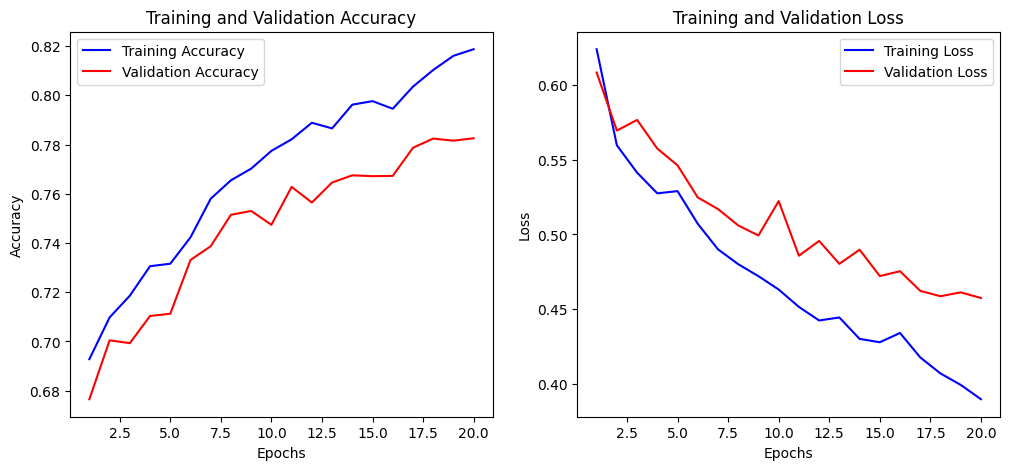

In [ ]:
import matplotlib.pyplot as plt

def plot_training_history(history):
    acc = history.history['accuracy']
    val_acc = history.history['val_accuracy']
    loss = history.history['loss']
    val_loss = history.history['val_loss']
    epochs = range(1, len(acc) + 1)

    plt.figure(figsize=(12, 5))

    # Plot accuracy
    plt.subplot(1, 2, 1)
    plt.plot(epochs, acc, 'b-', label='Training Accuracy')
    plt.plot(epochs, val_acc, 'r-', label='Validation Accuracy')
    plt.title('Training and Validation Accuracy')
    plt.xlabel('Epochs')
    plt.ylabel('Accuracy')
    plt.legend()

    # Plot loss
    plt.subplot(1, 2, 2)
    plt.plot(epochs, loss, 'b-', label='Training Loss')
    plt.plot(epochs, val_loss, 'r-', label='Validation Loss')
    plt.title('Training and Validation Loss')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.legend()

    plt.show()

# Visualize the training history
plot_training_history(history)


### Results

1. Accuracy Plot:
   - Both training and validation accuracy show an overall upward trend, which is positive.The training accuracy (blue) consistently outperforms validation accuracy (red line), indicating some degree of overfitting.
   - Validation accuracy seems to plateau around 0.78 (78%) by the end of training.

2. Loss Plot:
   - Both training and validation loss decrease over time.The training loss (blue line) decreases more rapidly and to a lower level than validation loss (red line), again indicating overfitting.
   - Validation loss shows more fluctuation but generally decreases, stabilizing around 0.45-0.46 by the end of training.
In general, the model shows good learning progress

### Visualize predictions
* Based on the visual comparison of the images below, the U-Net model demonstrates good overall performance in identifying the main subjects(input imiages) in the image segmentation task.

* The predicted mask successfully captures the general shape and location of the foreground elements. However, it lacks the precision and sharp edges seen in the true mask, instead producing a gradient of probabilities from high confidence (yellow) in the center to lower confidence (blue) at the edges.

This softness in the predicted mask, along with some faint false positives in the background, suggests that though the model effectively distinguishes foreground from background, there's room for improvement in boundary precision and confidence.
These observations align with the previously reported accuracy of 80.99%, indicating a model that performs well but has potential for refinement in edge detection and overall segmentation clarity.

In [ ]:
def display(display_list):
    plt.figure(figsize=(15, 15))
    title = ['Input Image', 'True Mask', 'Predicted Mask']
    for i in range(len(display_list)):
        plt.subplot(1, len(display_list), i + 1)
        plt.title(title[i])
        plt.imshow(tf.keras.preprocessing.image.array_to_img(display_list[i]))
        plt.axis('off')
    plt.show()

def visualize_predictions(dataset, num_samples=3):
    for images, masks in dataset.take(num_samples):
        preds = model.predict(images)
        for i in range(len(images)):
            display([images[i], masks[i], preds[i]])

# Visualize a few predictions
visualize_predictions(test_dataset, num_samples=3)


## Modified Unet model.

This code implements a modification to the U-Net architecture by replacing the Conv2DTranspose layers with a combination of UpSampling2D and standard Conv2D layers in the decoder path.

* The code uses UpSampling2D with bilinear interpolation instead of Conv2DTranspose for upsampling in the decoder path.

* Architecture Modification: After each upsampling operation, a standard Conv2D layer is applied to learn the features at the new resolution.

* The model is trained for 20 epochs, similar to the original model, allowing for a direct comparison.




In [ ]:
from tensorflow.keras.layers import UpSampling2D
# Modified unet model building

def build_unet_with_upsampling(input_shape):
    inputs = Input(input_shape)

    # Encoder
    c1 = Conv2D(64, (3, 3), activation='relu', padding='same')(inputs)
    c1 = Conv2D(64, (3, 3), activation='relu', padding='same')(c1)
    p1 = MaxPooling2D((2, 2))(c1)

    c2 = Conv2D(128, (3, 3), activation='relu', padding='same')(p1)
    c2 = Conv2D(128, (3, 3), activation='relu', padding='same')(c2)
    p2 = MaxPooling2D((2, 2))(c2)

    c3 = Conv2D(256, (3, 3), activation='relu', padding='same')(p2)
    c3 = Conv2D(256, (3, 3), activation='relu', padding='same')(c3)
    p3 = MaxPooling2D((2, 2))(c3)

    c4 = Conv2D(512, (3, 3), activation='relu', padding='same')(p3)
    c4 = Conv2D(512, (3, 3), activation='relu', padding='same')(c4)
    p4 = MaxPooling2D(pool_size=(2, 2))(c4)

    # Bottleneck
    c5 = Conv2D(1024, (3, 3), activation='relu', padding='same')(p4)
    c5 = Conv2D(1024, (3, 3), activation='relu', padding='same')(c5)

    # Decoder using UpSampling2D and Conv2D
    u6 = UpSampling2D((2, 2), interpolation='bilinear')(c5)
    u6 = Conv2D(512, (2, 2), activation='relu', padding='same')(u6)
    u6 = concatenate([u6, c4])
    c6 = Conv2D(512, (3, 3), activation='relu', padding='same')(u6)
    c6 = Conv2D(512, (3, 3), activation='relu', padding='same')(c6)

    u7 = UpSampling2D((2, 2), interpolation='bilinear')(c6)
    u7 = Conv2D(256, (2, 2), activation='relu', padding='same')(u7)
    u7 = concatenate([u7, c3])
    c7 = Conv2D(256, (3, 3), activation='relu', padding='same')(u7)
    c7 = Conv2D(256, (3, 3), activation='relu', padding='same')(c7)

    u8 = UpSampling2D((2, 2), interpolation='bilinear')(c7)
    u8 = Conv2D(128, (2, 2), activation='relu', padding='same')(u8)
    u8 = concatenate([u8, c2])
    c8 = Conv2D(128, (3, 3), activation='relu', padding='same')(u8)
    c8 = Conv2D(128, (3, 3), activation='relu', padding='same')(c8)

    u9 = UpSampling2D((2, 2), interpolation='bilinear')(c8)
    u9 = Conv2D(64, (2, 2), activation='relu', padding='same')(u9)
    u9 = concatenate([u9, c1])
    c9 = Conv2D(64, (3, 3), activation='relu', padding='same')(u9)
    c9 = Conv2D(64, (3, 3), activation='relu', padding='same')(c9)

    outputs = Conv2D(1, (1, 1), activation='sigmoid')(c9)

    model = Model(inputs=[inputs], outputs=[outputs])
    return model

# Compile the new model
model = build_unet_with_upsampling(input_shape)
model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=0.001), loss='binary_crossentropy', metrics=['accuracy'])

# Train the new model
history = model.fit(train_dataset, epochs=20, validation_data=val_dataset)


Epoch 1/20
64/64 ━━━━━━━━━━━━━━━━━━━━ 200s 2s/step - accuracy: 0.6865 - loss: 0.6322 - val_accuracy: 0.6860 - val_loss: 0.5936
Epoch 2/20
64/64 ━━━━━━━━━━━━━━━━━━━━ 47s 657ms/step - accuracy: 0.7144 - loss: 0.5442 - val_accuracy: 0.7144 - val_loss: 0.5448
Epoch 3/20
64/64 ━━━━━━━━━━━━━━━━━━━━ 51s 660ms/step - accuracy: 0.7414 - loss: 0.5089 - val_accuracy: 0.7211 - val_loss: 0.5590
Epoch 4/20
64/64 ━━━━━━━━━━━━━━━━━━━━ 47s 662ms/step - accuracy: 0.7589 - loss: 0.4936 - val_accuracy: 0.7482 - val_loss: 0.5075
Epoch 5/20
64/64 ━━━━━━━━━━━━━━━━━━━━ 82s 672ms/step - accuracy: 0.7705 - loss: 0.4733 - val_accuracy: 0.7606 - val_loss: 0.5345
Epoch 6/20
64/64 ━━━━━━━━━━━━━━━━━━━━ 83s 659ms/step - accuracy: 0.7678 - loss: 0.4797 - val_accuracy: 0.7480 - val_loss: 0.5089
Epoch 7/20
64/64 ━━━━━━━━━━━━━━━━━━━━ 82s 667ms/step - accuracy: 0.7774 - loss: 0.4635 - val_accuracy: 0.7479 - val_loss: 0.5027
Epoch 8/20
64/64 ━━━━━━━━━━━━━━━━━━━━ 47s 663ms/step - accuracy: 0.7674 - loss: 0.4783 - val_accura

In [ ]:
# Evaluate the model on the test data
test_loss, test_accuracy = model.evaluate(test_dataset)
print(f'Test accuracy: {test_accuracy:.4f}, Test loss: {test_loss:.4f}')



14/14 ━━━━━━━━━━━━━━━━━━━━ 4s 291ms/step - accuracy: 0.8012 - loss: 0.4289
Test accuracy: 0.8049, Test loss: 0.4254


### Accuracy and Loss plots of modified Model

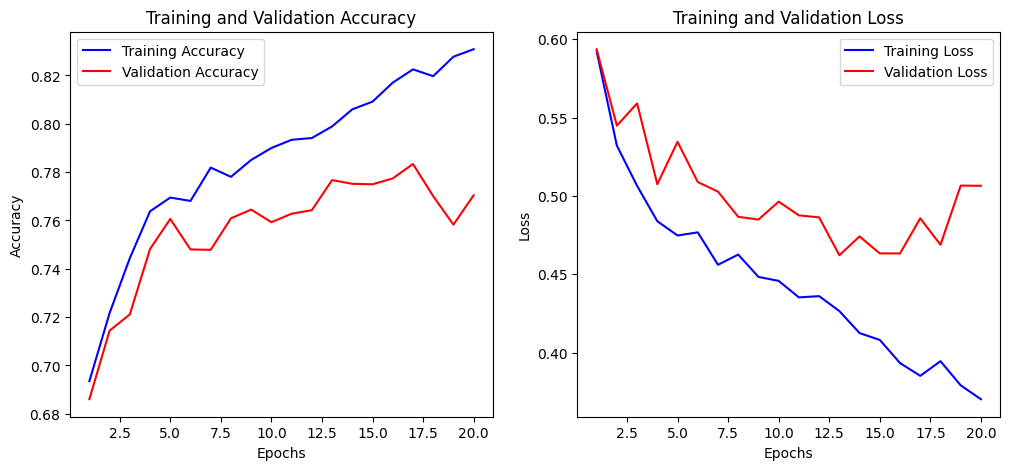

In [ ]:
import matplotlib.pyplot as plt

def plot_training_history(history):
    # Retrieve the data from the history object
    acc = history.history['accuracy']
    val_acc = history.history['val_accuracy']
    loss = history.history['loss']
    val_loss = history.history['val_loss']
    epochs = range(1, len(acc) + 1)

    plt.figure(figsize=(12, 5))

    # Plot accuracy
    plt.subplot(1, 2, 1)
    plt.plot(epochs, acc, 'b-', label='Training Accuracy')
    plt.plot(epochs, val_acc, 'r-', label='Validation Accuracy')
    plt.title('Training and Validation Accuracy')
    plt.xlabel('Epochs')
    plt.ylabel('Accuracy')
    plt.legend()

    # Plot loss
    plt.subplot(1, 2, 2)
    plt.plot(epochs, loss, 'b-', label='Training Loss')
    plt.plot(epochs, val_loss, 'r-', label='Validation Loss')
    plt.title('Training and Validation Loss')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.legend()

    plt.show()

# Call the function to plot the history
plot_training_history(history)


### Results

1. Accuracy Plot:
   - The training accuracy (blue line) shows a similar upward trend to the original model, reaching about 83% by epoch 20.
   - The validation accuracy (red line) is more unstable compared to the original model, with more fluctuations.
   - The gap between training and validation accuracy is still present, indicating some overfitting.
   - The validation accuracy peaks around 78% but drops towards the end, finishing lower than the original model.

2. Loss Plot:
   - The training loss (blue line) decreases steadily, similar to the original model.
   - The validation loss (red line) shows more instability compared to the original model, with significant fluctuations.
   - There's a rise in validation loss towards the end of training, which wasn't present in the original model.

* The modified model shows more instability in validation metrics, particularly in later epochs.

* The rise in validation loss and drop in validation accuracy in later epochs suggest that this model might be more prone to overfitting or struggling to generalize compared to the original.

Comparison to the original model:
1. Performance: The peak validation accuracy seems similar (around 78%), but the final performance appears slightly worse due to the late-stage decline.
2. Stability: This model shows less stable validation metrics, which could make it less reliable in practice.
3. The modified architecture seems to learn quickly initially but struggles to maintain performance in later epochs.




### Visualize Predictions


In [ ]:
def display(display_list):
    plt.figure(figsize=(15, 15))
    title = ['Input Image', 'True Mask', 'Predicted Mask']
    for i in range(len(display_list)):
        plt.subplot(1, len(display_list), i + 1)
        plt.title(title[i])
        plt.imshow(tf.keras.preprocessing.image.array_to_img(display_list[i]))
        plt.axis('off')
    plt.show()

def visualize_predictions(model, dataset, num_samples=3):
    for images, true_masks in dataset.take(num_samples):
        preds = model.predict(images)
        for i in range(len(images)):
            display([images[i], true_masks[i], preds[i]])

# Visualize predictions
visualize_predictions(model, test_dataset, num_samples=3)


### Visual comparison with of the modified Unet model with the original U net model

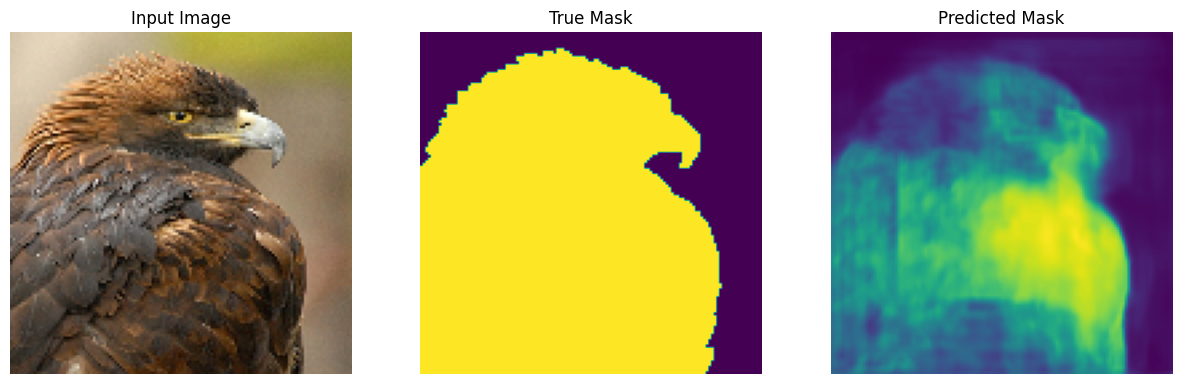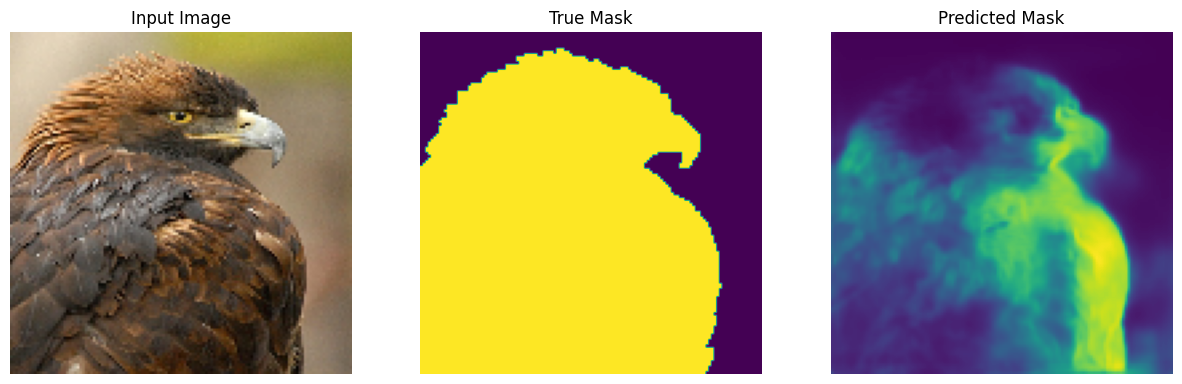


### The image at the top is that from the Original U net model and the image below is from the modified model.
Some identifiable differences between both images are:

1. Overall Shape Recognition:
   - Both models capture the general shape of the bird.
   - The modified model (image below) has sharper boundaries and outline the shapes of the objects more clearly than the original model.

2. Confidence Gradient:
   - Both models display a confidence gradient, but the modified model shows a more pronounced color variation from yellow to green to blue.
   - The initial model seems to have a higher overall confidence (more yellow areas) in its prediction.

3. Background Handling:
   - Both models handle the background well, with minimal false positives.
   - The modified model shows a bit more uncertainty in the background (more blue tones) compared to the more uniform background in the initial model.

Both models are good enough but the choice of which to use between these models would depend on the specific requirements for which the image segmentation is being done.